# Import & Data Loading

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns
sns.set_style("whitegrid")

In [37]:
df = pd.read_csv(r"C:\Users\admin\Downloads\ecommerce_customer_data_custom_ratios.csv.zip")

# Data Exploration

In [38]:
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [39]:
df.columns

Index(['Customer ID', 'Purchase Date', 'Product Category', 'Product Price',
       'Quantity', 'Total Purchase Amount', 'Payment Method', 'Customer Age',
       'Returns', 'Customer Name', 'Age', 'Gender', 'Churn'],
      dtype='str')

In [40]:
df.shape

(250000, 13)

In [41]:
df.dtypes

Customer ID                int64
Purchase Date                str
Product Category             str
Product Price              int64
Quantity                   int64
Total Purchase Amount      int64
Payment Method               str
Customer Age               int64
Returns                  float64
Customer Name                str
Age                        int64
Gender                       str
Churn                      int64
dtype: object

In [42]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Customer ID            250000 non-null  int64  
 1   Purchase Date          250000 non-null  str    
 2   Product Category       250000 non-null  str    
 3   Product Price          250000 non-null  int64  
 4   Quantity               250000 non-null  int64  
 5   Total Purchase Amount  250000 non-null  int64  
 6   Payment Method         250000 non-null  str    
 7   Customer Age           250000 non-null  int64  
 8   Returns                202404 non-null  float64
 9   Customer Name          250000 non-null  str    
 10  Age                    250000 non-null  int64  
 11  Gender                 250000 non-null  str    
 12  Churn                  250000 non-null  int64  
dtypes: float64(1), int64(7), str(5)
memory usage: 24.8 MB


In [43]:
df.describe()

,Customer ID,Product Price,Quantity,Total Purchase Amount,Customer Age,Returns,Age,Churn
count,250000.00000,250000.000000,250000.000000,250000.000000,250000.000000,202404.000000,250000.000000,250000.000000
mean,25004.03624,254.659512,2.998896,2725.370732,43.940528,0.497861,43.940528,0.199496
std,14428.27959,141.568577,1.414694,1442.933565,15.350246,0.499997,15.350246,0.399622
min,1.00000,10.000000,1.000000,100.000000,18.000000,0.000000,18.000000,0.000000
25%,12497.75000,132.000000,2.000000,1477.000000,31.000000,0.000000,31.000000,0.000000
50%,25018.00000,255.000000,3.000000,2724.000000,44.000000,0.000000,44.000000,0.000000
75%,37506.00000,377.000000,4.000000,3974.000000,57.000000,1.000000,57.000000,0.000000
max,50000.00000,500.000000,5.000000,5350.000000,70.000000,1.000000,70.000000,1.000000


In [44]:
df.isnull().sum()

Customer ID                  0
Purchase Date                0
Product Category             0
Product Price                0
Quantity                     0
Total Purchase Amount        0
Payment Method               0
Customer Age                 0
Returns                  47596
Customer Name                0
Age                          0
Gender                       0
Churn                        0
dtype: int64

# Data Cleaning

In [45]:
# Cleaning
df.head()

,Customer ID,Purchase Date,Product Category,Product Price,Quantity,Total Purchase Amount,Payment Method,Customer Age,Returns,Customer Name,Age,Gender,Churn
0,46251,2020-09-08 09:38:32,Electronics,12,3,740,Credit Card,37,0.0,Christine Hernandez,37,Male,0
1,46251,2022-03-05 12:56:35,Home,468,4,2739,PayPal,37,0.0,Christine Hernandez,37,Male,0
2,46251,2022-05-23 18:18:01,Home,288,2,3196,PayPal,37,0.0,Christine Hernandez,37,Male,0
3,46251,2020-11-12 13:13:29,Clothing,196,1,3509,PayPal,37,0.0,Christine Hernandez,37,Male,0
4,13593,2020-11-27 17:55:11,Home,449,1,3452,Credit Card,49,0.0,James Grant,49,Female,1


In [46]:
## Преобразование даты покупки в формат datetime для анализа по времени
df['Purchase Date'] = pd.to_datetime(df['Purchase Date'])

In [47]:
## Избавиться от Nan значений в Returns column
df['Returns'] = df['Returns'].fillna(0).astype(int)

In [48]:
df['year']=df['Purchase Date'].dt.year
df['month']=df['Purchase Date'].dt.month
df['day']=df['Purchase Date'].dt.day_name()

In [49]:
# customer age and age столбцы одинаовые, то есть можем удалить age столбец
df.drop(df['Age'], inplace = True)

In [50]:
# Дубликаты
df.duplicated().sum()

np.int64(0)

# Hypotheses and questiosn to answer

In [51]:
# - Какие категории товаров приносят наибольшую выручку?
# - Какие клиенты генерируют основную выручку?
# - Есть ли сезонность в покупках?
# - Связаны ли возвраты с проблемами продукта?
# - Влияют ли возвраты на churn?

In [52]:
f'Number of customers : {df['Customer ID'].nunique()}, total number of rows in the dataset: {len(df)}'
# В датасете содержится 249 947 записей о покупках, при этом количество уникальных покупателей составляет 49 665 человек. 
# Это означает, что в среднем один покупатель совершает около 5 транзакций.

'Number of customers : 49665, total number of rows in the dataset: 249947'

## Revenue Analysis

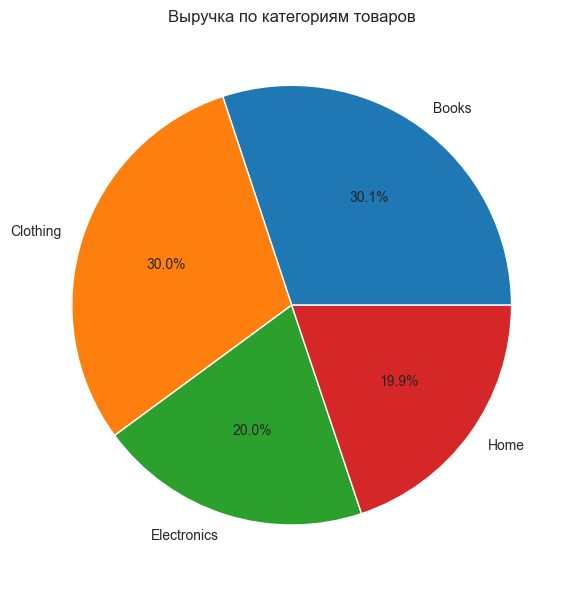

In [53]:
# Какие категории товаров приносят наибольшую выручку?
a = df['Total Purchase Amount'].groupby([df['Product Category']]).sum()
plt.figure(figsize = (6,6))
plt.pie(a, labels = a.index, autopct='%1.1f%%')
plt.title("Выручка по категориям товаров")

plt.tight_layout()
plt.show()


In [103]:
customer_value

Customer ID
36437    55339
39817    51718
26977    48497
5844     46541
3576     46518
         ...  
37371      167
33238      162
13297      157
1382       153
47899      110
Name: Total Purchase Amount, Length: 49665, dtype: int64

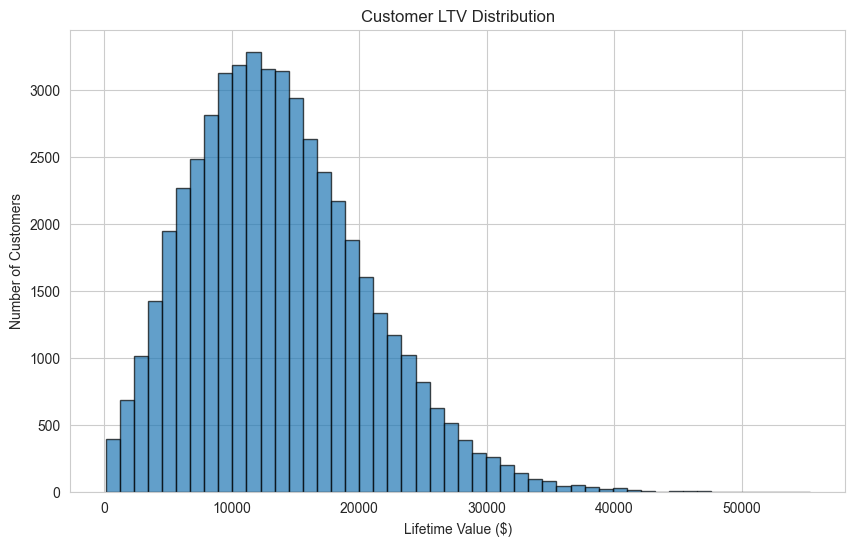

In [116]:
customer_value = df.groupby('Customer ID')['Total Purchase Amount'].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
plt.hist(customer_value, bins=50, edgecolor='black', alpha=0.7)
plt.title("Customer LTV Distribution")
plt.xlabel("Lifetime Value ($)")
plt.ylabel("Number of Customers")
plt.show()

# Churn Analysis

In [54]:
df['Customer Age'].max()

np.int64(70)

In [55]:
# Average Order Value (AOV)
aov = df['Total Purchase Amount'].groupby(df['Customer ID']).agg('mean')

In [119]:
today = df['Purchase Date'].max()
last_purchase = df.groupby('Customer ID')['Purchase Date'].max()
recency = (today - last_purchase).dt.days

In [57]:
churn = df.groupby('Customer ID')['Churn'].max()

In [58]:
insights = pd.DataFrame({
    'Recency': recency,
    'AOV': aov, 
    "Churn": churn
})

In [59]:
insights.head()

,Recency,AOV,Churn
Customer ID,,,
1,57,3491.000000,0
2,298,2662.666667,0
3,88,2823.375000,0
4,126,2178.750000,1
5,170,1565.500000,0


In [60]:
insights.groupby('Churn')['Recency'].agg(['mean', 'median', 'count'])

,mean,median,count
Churn,,,
0,260.892659,184.0,39724
1,258.581430,185.0,9941


In [61]:
insights.groupby('Churn')['AOV'].agg(['mean', 'median'])

,mean,median
Churn,,
0,2723.910691,2726.0
1,2728.026187,2741.8


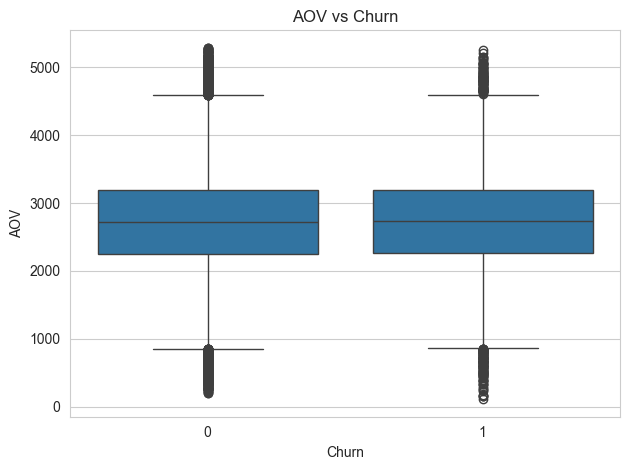

In [62]:
sns.boxplot(x='Churn', y='AOV', data=insights)
plt.title('AOV vs Churn')

plt.tight_layout()
plt.show()

In [63]:
frequency = df.groupby('Customer ID').size()

insights['Frequency'] = frequency

In [64]:
insights['Freq_segment'] = pd.qcut(insights['Frequency'], q = 3, labels = ['Low', 'Medium', 'High'])

In [65]:
insights.groupby('Freq_segment')['Churn'].mean()

Freq_segment
Low       0.203033
Medium    0.197257
High      0.198876
Name: Churn, dtype: float64

In [66]:
# Анализ сегментов частоты покупок показал, что уровень churn практически не различается между группами пользователей. Это указывает на то, что частота покупок не является значимым фактором оттока в датасете.
# Беря во внимание результаты(Recency, AOV), можно сделать вывод, что поведенческие метрики, доступные в данных, не объясняют churn.
# Вероятно, ключевые причины оттока связаны с факторами, не представленными в датасете, такими как пользовательский опыт, качество продукта.

In [ ]:
churn_return = df.groupby('Churn')['Returns'].mean()
churn_total = df.groupby('Churn')['Total Purchase Amount'].mean()

new = pd.DataFrame({
    "Returns": churn_return,
    "Total Purchase Amount": churn_total
})
# Уровень возвратов и средний размер покупки практически одинаков у клиентов с churn и без churn.
# Это говорит о том, что они, вероятно, не являются ключевым фактором оттока пользователей.
new

,Returns,Total Purchase Amount
Churn,,
0,0.402724,2724.931098
1,0.404476,2727.785690


In [ ]:
df.groupby('Product Category')['Churn'].mean().sort_values(ascending=False)
# Уровень churn примерно одинаков во всех категориях товаров.Отсюда следует, что категория продукта не является ключевым фактором оттока. Главная причина：
# В текущем датасете отсутствуют важные факторы, влияющие на churn

Product Category
Home           0.202019
Books          0.199266
Electronics    0.198852
Clothing       0.198529
Name: Churn, dtype: float64

# Gnder distribution

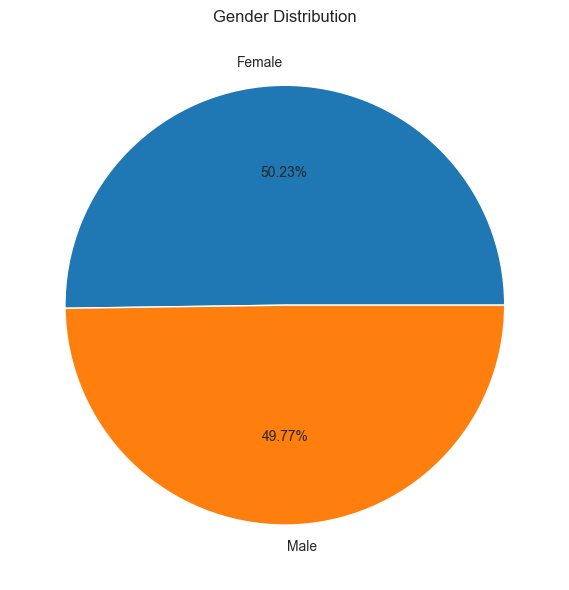

In [93]:
genderc = df['Gender'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(genderc,labels=genderc.index,autopct='%1.2f%%')

plt.title('Gender Distribution')
plt.tight_layout()
plt.show()

In [68]:
df.groupby('Gender').agg({'Customer ID': 'count', "Returns": 'sum', 'Total Purchase Amount':'sum', "Churn": "count"})

,Customer ID,Returns,Total Purchase Amount,Churn
Gender,,,,
Female,125542,50605,342422599,125542
Male,124405,50142,338808104,124405


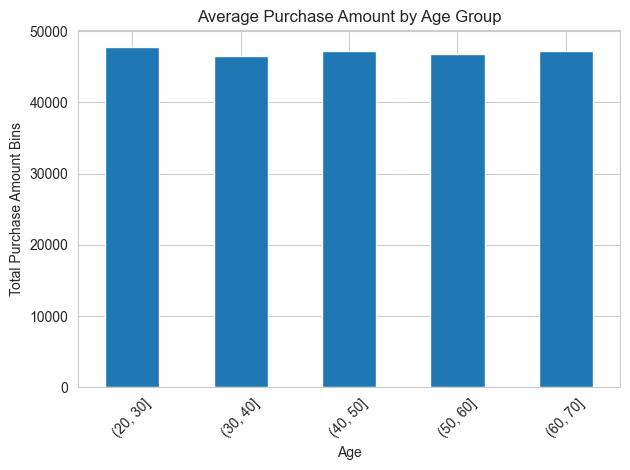

binned
(20, 30]    47715
(30, 40]    46482
(40, 50]    47245
(50, 60]    46810
(60, 70]    47260
Name: count, dtype: int64

In [69]:
binss = [i + 10 for i in range(10, 70, 10)]
df['binned'] = pd.cut(df['Customer Age'], bins=binss)
counts = df['binned'].value_counts().sort_index()

counts.plot(kind='bar', title='Average Purchase Amount by Age Group')
plt.ylabel('Total Purchase Amount Bins')
plt.xlabel('Age')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
counts

## patterns in purchase timing

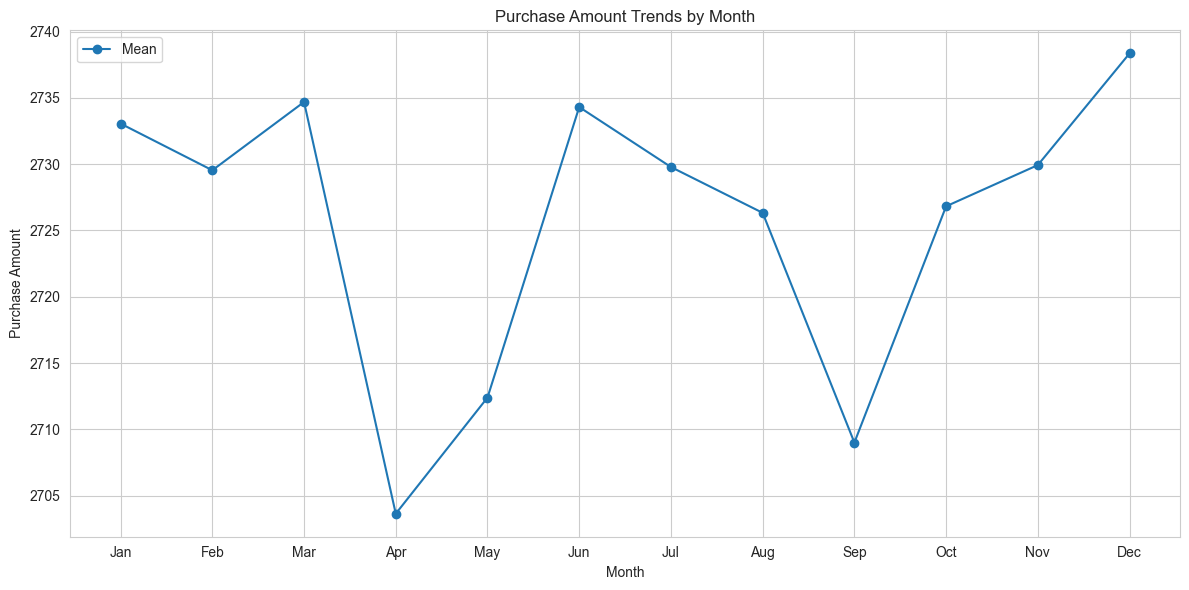

In [70]:
monthly_trend = df.groupby(df['Purchase Date'].dt.month)['Total Purchase Amount'].agg('mean')

plt.figure(figsize=(12, 6))
plt.plot(monthly_trend.index, monthly_trend.values, marker='o', label='Mean')
plt.xlabel('Month')
plt.ylabel('Purchase Amount')
plt.title('Purchase Amount Trends by Month')
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend()
plt.tight_layout()
plt.show()
# Средний размер покупки остается относительно стабильным в течение года, с заметными снижениями в апреле и сентябре.
# Это может свидетельствовать о том, что в целом поведение пользователей по расходам остается устойчивым, однако в отдельные периоды наблюдается краткосрочное снижение спроса.

In [71]:
# Какие категории имеют высокий уровень возвратов?
num_returns = df['Returns'].groupby(df['Product Category']).agg('mean')
print(num_returns)

Product Category
Books          0.403512
Clothing       0.401375
Electronics    0.403902
Home           0.404137
Name: Returns, dtype: float64


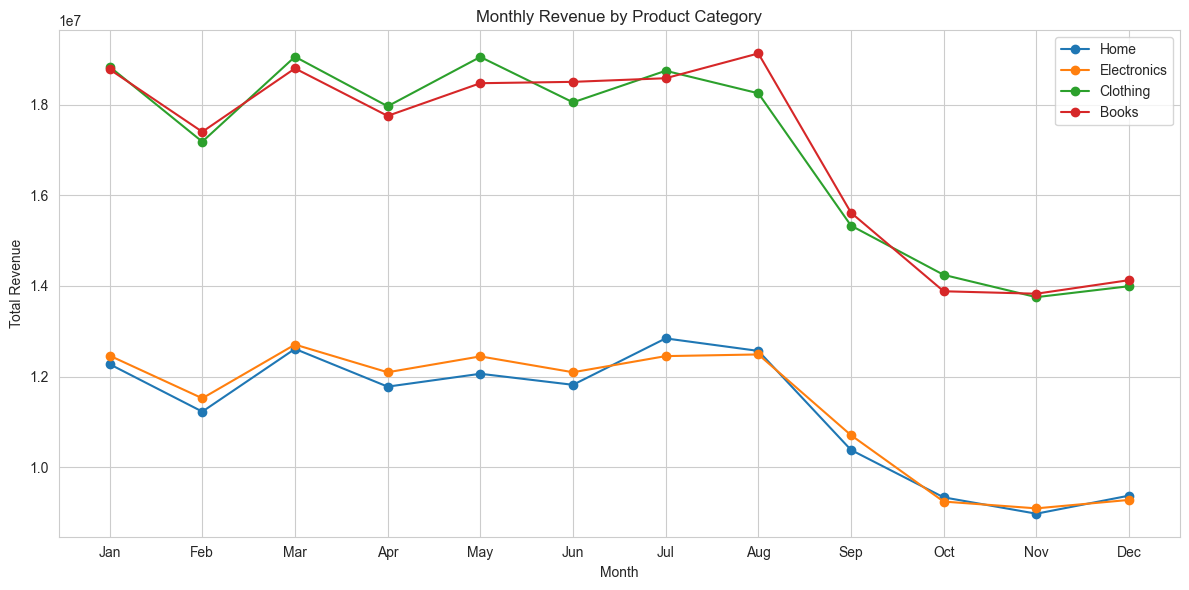

In [72]:
plt.figure(figsize=(12, 6))

rev_per_month = df['Total Purchase Amount'].groupby([df['Product Category'], df['Purchase Date'].dt.month]).sum()

categories = ['Home', 'Electronics', 'Clothing', 'Books']

for category in categories:
    data = rev_per_month.loc[category]
    
    plt.plot(data.index, data.values, marker='o', label=category)

plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.title("Monthly Revenue by Product Category")

plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                          'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])

plt.legend()
plt.tight_layout()
plt.show()

# Динамика выручки показывает схожие сезонные паттерны по всем категориям товаров, с заметным снижением после сентября.
# Это может указывать на сезонность спроса, при которой активность пользователей снижается к концу года.
# Возмоэное решение：запуск маркетинговых кампаний в Q4 для компенсации снижения продаж.

In [ ]:
# Key Business Problems
# Сезонное снижение выручки в Q4
# Отсутствие понимания причин churn
# Высокий уровень возвратов

In [ ]:
# Выводы 
# Уровень возвратов стабильно высокий во всех категориях товаров, что может указывать на проблемы с качеством продукции, несоответствием ожиданий пользователей или процессами доставки и выполнения заказов.
# Выручка снижается после сентября, что свидетельствует о наличии сезонного фактора и падении пользовательской активности в конце года.
# Причины оттока пользователей (churn) не выявлены на основе доступных данных, что указывает на отсутствие ключевых признаков, необходимых для объяснения поведения пользователей.
# Выручка в значительной степени зависит от небольшой группы клиентов, что создает риск потери дохода при их оттоке.